### Understand the dataset better

A: traits x characters (464 x 2000)

Notes about the SVD:

- A * V : traits x characters
- U.T * A : archertype space (basis for characters) -- 464 x 2000 (traits x PC of archetypes)

Notes:

1. We could just use archetype_df as input to the clustering/classification model ... but there are a lot of 0s
2. We could normalize this - does this deal with stories having differing numbers of primary characters?

In [78]:
import numpy as np
import pandas as pd

In [79]:
# show all columns
pd.set_option('display.max_columns', None)

Load & Preprocess Data

In [80]:
df = pd.read_csv('../prepared_data/characters_with_imdb.csv')

In [81]:
# Build one genre label per story (keep only comedy/drama)
story_genre = (
    df[['story_name', 'imdb_genres']]
    .dropna()
    .drop_duplicates('story_name')
    .copy()
)

def to_genre(g):
    g = g.lower()
    if 'comedy' in g:
        return 'comedy'
    if 'drama' in g:
        return 'drama'
    return np.nan

story_genre['genre'] = story_genre['imdb_genres'].apply(to_genre)
story_genre = story_genre.dropna(subset=['genre'])
story_genre['is_comedy'] = (story_genre['genre'] == 'comedy').astype(int)

# Add genre to character-level data before archetype aggregation
df = df.merge(
    story_genre[['story_name', 'genre', 'is_comedy']],
    on='story_name',
    how='left'
)

# Keep only comedy/drama stories
df = df[df['genre'].isin(['comedy', 'drama'])]

df[['story_name', 'genre', 'is_comedy']].head()

,story_name,genre,is_comedy
0,My Little Pony: Friendship Is Magic,comedy,1.0
1,My Little Pony: Friendship Is Magic,comedy,1.0
2,My Little Pony: Friendship Is Magic,comedy,1.0
3,My Little Pony: Friendship Is Magic,comedy,1.0
4,My Little Pony: Friendship Is Magic,comedy,1.0


In [82]:
# For each story_name, group characters by their primary archetype frequency,
# while keeping genre columns that were added before this groupby.
archetype_freqs = (
    df.groupby(['story_name', 'genre', 'is_comedy'])['primary_archetype']
    .value_counts()
    .unstack(fill_value=0)
)

# Convert grouped frequencies to dataframe and keep story_name as index
archetype_freqs_df = archetype_freqs.reset_index().set_index('story_name')

# Archetype feature columns (exclude metadata columns)
archetype_cols = [c for c in archetype_freqs_df.columns if c not in ['genre', 'is_comedy']]

archetype_freqs_df.head()

primary_archetype,genre,is_comedy,Adventurer,Adventurer-Angel,Adventurer-Angel-Diva,Adventurer-Angel-Hero,Adventurer-Angel-Outcast,Adventurer-Brute,Adventurer-Brute-Demon,Adventurer-Brute-Hero,Adventurer-Demon,Adventurer-Demon-Diva,Adventurer-Demon-Fool,Adventurer-Demon-Hero,Adventurer-Demon-Lone Wolf,Adventurer-Demon-Outcast,Adventurer-Diva,Adventurer-Diva-Angel,Adventurer-Diva-Demon,Adventurer-Diva-Hero,Adventurer-Fool-Demon,Adventurer-Fool-Outcast,Adventurer-Geek-Outcast,Adventurer-Hero,Adventurer-Hero-Angel,Adventurer-Hero-Brute,Adventurer-Hero-Demon,Adventurer-Hero-Diva,Adventurer-Hero-Geek,Adventurer-Hero-Outcast,Adventurer-Lone Wolf-Demon,Adventurer-Lone Wolf-Hero,Adventurer-Outcast,Adventurer-Outcast-Angel,Adventurer-Outcast-Demon,Adventurer-Outcast-Diva,Adventurer-Outcast-Hero,Adventurer-Outcast-Lone Wolf,Adventurer-Sophisticate-Hero,Angel,Angel-Adventurer,Angel-Adventurer-Diva,Angel-Adventurer-Hero,Angel-Adventurer-Outcast,Angel-Brute,Angel-Brute-Adventurer,Angel-Brute-Hero,Angel-Diva-Adventurer,Angel-Diva-Hero,Angel-Diva-Outcast,Angel-Diva-Traditionalist,Angel-Fool,Angel-Geek-Adventurer,Angel-Geek-Hero,Angel-Geek-Outcast,Angel-Hero,Angel-Hero-Adventurer,Angel-Hero-Diva,Angel-Hero-Lone Wolf,Angel-Hero-Traditionalist,Angel-Lone Wolf-Hero,Angel-Outcast,Angel-Outcast-Adventurer,Angel-Outcast-Diva,Angel-Outcast-Hero,Angel-Outcast-Traditionalist,Angel-Traditionalist-Hero,Angel-Traditionalist-Outcast,Brute-Adventurer,Brute-Adventurer-Angel,Brute-Adventurer-Demon,Brute-Adventurer-Diva,Brute-Adventurer-Fool,Brute-Adventurer-Hero,Brute-Angel,Brute-Angel-Adventurer,Brute-Angel-Hero,Brute-Angel-Lone Wolf,Brute-Demon,Brute-Demon-Adventurer,Brute-Demon-Diva,Brute-Demon-Hero,Brute-Demon-Outcast,Brute-Demon-Traditionalist,Brute-Diva,Brute-Diva-Adventurer,Brute-Diva-Angel,Brute-Diva-Demon,Brute-Diva-Hero,Brute-Fool-Adventurer,Brute-Hero,Brute-Hero-Adventurer,Brute-Hero-Angel,Brute-Hero-Demon,Brute-Hero-Diva,Brute-Hero-Outcast,Brute-Hero-Traditionalist,Brute-Lone Wolf-Hero,Brute-Lone Wolf-Outcast,Brute-Outcast,Brute-Outcast-Adventurer,Brute-Outcast-Angel,Brute-Outcast-Demon,Brute-Outcast-Diva,Brute-Outcast-Hero,Brute-Traditionalist,Brute-Traditionalist-Demon,Brute-Traditionalist-Hero,Brute-Traditionalist-Outcast,Demon,Demon-Adventurer,Demon-Adventurer-Brute,Demon-Adventurer-Diva,Demon-Adventurer-Hero,Demon-Adventurer-Lone Wolf,Demon-Adventurer-Outcast,Demon-Brute-Adventurer,Demon-Brute-Diva,Demon-Brute-Hero,Demon-Brute-Outcast,Demon-Diva,Demon-Diva-Adventurer,Demon-Diva-Hero,Demon-Diva-Traditionalist,Demon-Fool-Diva,Demon-Fool-Outcast,Demon-Geek-Adventurer,Demon-Geek-Hero,Demon-Hero,Demon-Hero-Adventurer,Demon-Hero-Diva,Demon-Hero-Geek,Demon-Hero-Lone Wolf,Demon-Hero-Outcast,Demon-Hero-Traditionalist,Demon-Lone Wolf-Adventurer,Demon-Lone Wolf-Hero,Demon-Lone Wolf-Outcast,Demon-Outcast,Demon-Outcast-Adventurer,Demon-Outcast-Fool,Demon-Outcast-Hero,Demon-Outcast-Lone Wolf,Demon-Outcast-Traditionalist,Demon-Sophisticate-Hero,Demon-Traditionalist-Diva,Demon-Traditionalist-Hero,Diva,Diva-Adventurer,Diva-Adventurer-Angel,Diva-Adventurer-Demon,Diva-Adventurer-Fool,Diva-Adventurer-Hero,Diva-Adventurer-Outcast,Diva-Angel,Diva-Angel-Adventurer,Diva-Angel-Brute,Diva-Angel-Hero,Diva-Angel-Outcast,Diva-Demon,Diva-Demon-Adventurer,Diva-Demon-Brute,Diva-Demon-Fool,Diva-Demon-Hero,Diva-Demon-Traditionalist,Diva-Fool-Adventurer,Diva-Fool-Outcast,Diva-Geek-Adventurer,Diva-Geek-Demon,Diva-Geek-Hero,Diva-Geek-Outcast,Diva-Hero,Diva-Hero-Adventurer,Diva-Hero-Angel,Diva-Hero-Brute,Diva-Hero-Demon,Diva-Hero-Outcast,Diva-Hero-Traditionalist,Diva-Outcast,Diva-Outcast-Adventurer,Diva-Outcast-Angel,Diva-Outcast-Hero,Diva-Outcast-Traditionalist,Diva-Sophisticate-Adventurer,Diva-Sophisticate-Hero,Diva-Traditionalist,Diva-Traditionalist-Angel,Diva-Traditionalist-Demon,Diva-Traditionalist-Hero,Diva-Traditionalist-Outcast,Fool-Adventurer,Fool-Adventurer-Demon,Fool-Adventurer-Diva,Fool-Adventurer-Outcast,Fool-Angel-Outcast,Fool-Brute-Adventurer,Fool-Demon-Adventurer

In [83]:
# Normalize archetype frequencies by total characters in each story
archetype_freqs_df_norm = archetype_freqs_df[archetype_cols].div(
    archetype_freqs_df[archetype_cols].sum(axis=1),
    axis=0
)

# Keep labels alongside normalized features
archetype_freqs_df_norm = archetype_freqs_df[['genre', 'is_comedy']].join(archetype_freqs_df_norm)
archetype_freqs_df_norm.head()

primary_archetype,genre,is_comedy,Adventurer,Adventurer-Angel,Adventurer-Angel-Diva,Adventurer-Angel-Hero,Adventurer-Angel-Outcast,Adventurer-Brute,Adventurer-Brute-Demon,Adventurer-Brute-Hero,Adventurer-Demon,Adventurer-Demon-Diva,Adventurer-Demon-Fool,Adventurer-Demon-Hero,Adventurer-Demon-Lone Wolf,Adventurer-Demon-Outcast,Adventurer-Diva,Adventurer-Diva-Angel,Adventurer-Diva-Demon,Adventurer-Diva-Hero,Adventurer-Fool-Demon,Adventurer-Fool-Outcast,Adventurer-Geek-Outcast,Adventurer-Hero,Adventurer-Hero-Angel,Adventurer-Hero-Brute,Adventurer-Hero-Demon,Adventurer-Hero-Diva,Adventurer-Hero-Geek,Adventurer-Hero-Outcast,Adventurer-Lone Wolf-Demon,Adventurer-Lone Wolf-Hero,Adventurer-Outcast,Adventurer-Outcast-Angel,Adventurer-Outcast-Demon,Adventurer-Outcast-Diva,Adventurer-Outcast-Hero,Adventurer-Outcast-Lone Wolf,Adventurer-Sophisticate-Hero,Angel,Angel-Adventurer,Angel-Adventurer-Diva,Angel-Adventurer-Hero,Angel-Adventurer-Outcast,Angel-Brute,Angel-Brute-Adventurer,Angel-Brute-Hero,Angel-Diva-Adventurer,Angel-Diva-Hero,Angel-Diva-Outcast,Angel-Diva-Traditionalist,Angel-Fool,Angel-Geek-Adventurer,Angel-Geek-Hero,Angel-Geek-Outcast,Angel-Hero,Angel-Hero-Adventurer,Angel-Hero-Diva,Angel-Hero-Lone Wolf,Angel-Hero-Traditionalist,Angel-Lone Wolf-Hero,Angel-Outcast,Angel-Outcast-Adventurer,Angel-Outcast-Diva,Angel-Outcast-Hero,Angel-Outcast-Traditionalist,Angel-Traditionalist-Hero,Angel-Traditionalist-Outcast,Brute-Adventurer,Brute-Adventurer-Angel,Brute-Adventurer-Demon,Brute-Adventurer-Diva,Brute-Adventurer-Fool,Brute-Adventurer-Hero,Brute-Angel,Brute-Angel-Adventurer,Brute-Angel-Hero,Brute-Angel-Lone Wolf,Brute-Demon,Brute-Demon-Adventurer,Brute-Demon-Diva,Brute-Demon-Hero,Brute-Demon-Outcast,Brute-Demon-Traditionalist,Brute-Diva,Brute-Diva-Adventurer,Brute-Diva-Angel,Brute-Diva-Demon,Brute-Diva-Hero,Brute-Fool-Adventurer,Brute-Hero,Brute-Hero-Adventurer,Brute-Hero-Angel,Brute-Hero-Demon,Brute-Hero-Diva,Brute-Hero-Outcast,Brute-Hero-Traditionalist,Brute-Lone Wolf-Hero,Brute-Lone Wolf-Outcast,Brute-Outcast,Brute-Outcast-Adventurer,Brute-Outcast-Angel,Brute-Outcast-Demon,Brute-Outcast-Diva,Brute-Outcast-Hero,Brute-Traditionalist,Brute-Traditionalist-Demon,Brute-Traditionalist-Hero,Brute-Traditionalist-Outcast,Demon,Demon-Adventurer,Demon-Adventurer-Brute,Demon-Adventurer-Diva,Demon-Adventurer-Hero,Demon-Adventurer-Lone Wolf,Demon-Adventurer-Outcast,Demon-Brute-Adventurer,Demon-Brute-Diva,Demon-Brute-Hero,Demon-Brute-Outcast,Demon-Diva,Demon-Diva-Adventurer,Demon-Diva-Hero,Demon-Diva-Traditionalist,Demon-Fool-Diva,Demon-Fool-Outcast,Demon-Geek-Adventurer,Demon-Geek-Hero,Demon-Hero,Demon-Hero-Adventurer,Demon-Hero-Diva,Demon-Hero-Geek,Demon-Hero-Lone Wolf,Demon-Hero-Outcast,Demon-Hero-Traditionalist,Demon-Lone Wolf-Adventurer,Demon-Lone Wolf-Hero,Demon-Lone Wolf-Outcast,Demon-Outcast,Demon-Outcast-Adventurer,Demon-Outcast-Fool,Demon-Outcast-Hero,Demon-Outcast-Lone Wolf,Demon-Outcast-Traditionalist,Demon-Sophisticate-Hero,Demon-Traditionalist-Diva,Demon-Traditionalist-Hero,Diva,Diva-Adventurer,Diva-Adventurer-Angel,Diva-Adventurer-Demon,Diva-Adventurer-Fool,Diva-Adventurer-Hero,Diva-Adventurer-Outcast,Diva-Angel,Diva-Angel-Adventurer,Diva-Angel-Brute,Diva-Angel-Hero,Diva-Angel-Outcast,Diva-Demon,Diva-Demon-Adventurer,Diva-Demon-Brute,Diva-Demon-Fool,Diva-Demon-Hero,Diva-Demon-Traditionalist,Diva-Fool-Adventurer,Diva-Fool-Outcast,Diva-Geek-Adventurer,Diva-Geek-Demon,Diva-Geek-Hero,Diva-Geek-Outcast,Diva-Hero,Diva-Hero-Adventurer,Diva-Hero-Angel,Diva-Hero-Brute,Diva-Hero-Demon,Diva-Hero-Outcast,Diva-Hero-Traditionalist,Diva-Outcast,Diva-Outcast-Adventurer,Diva-Outcast-Angel,Diva-Outcast-Hero,Diva-Outcast-Traditionalist,Diva-Sophisticate-Adventurer,Diva-Sophisticate-Hero,Diva-Traditionalist,Diva-Traditionalist-Angel,Diva-Traditionalist-Demon,Diva-Traditionalist-Hero,Diva-Traditionalist-Outcast,Fool-Adventurer,Fool-Adventurer-Demon,Fool-Adventurer-Diva,Fool-Adventurer-Outcast,Fool-Angel-Outcast,Fool-Brute-Adventurer,Fool-Demon-Adventurer

In [84]:
# Value counts of genres in archetype_freqs_df
archetype_freqs_df['genre'].value_counts()

genre
drama     188
comedy    139
Name: count, dtype: int64

In [85]:
# What are the most common primary archetypes across all stories?
archetype_freqs_df[archetype_cols].sum(axis=0).sort_values(ascending=False).head(20)

primary_archetype
Hero                     179
Angel-Hero                74
Adventurer                61
Hero-Demon                52
Demon                     43
Demon-Hero                39
Traditionalist-Hero       36
Hero-Angel                33
Adventurer-Hero           28
Angel                     27
Angel-Adventurer          25
Lone Wolf-Hero            20
Hero-Adventurer           19
Demon-Adventurer          18
Diva-Angel-Hero           17
Diva-Adventurer           16
Hero-Angel-Adventurer     15
Hero-Demon-Adventurer     14
Diva-Demon                14
Brute-Angel-Hero          14
dtype: int64

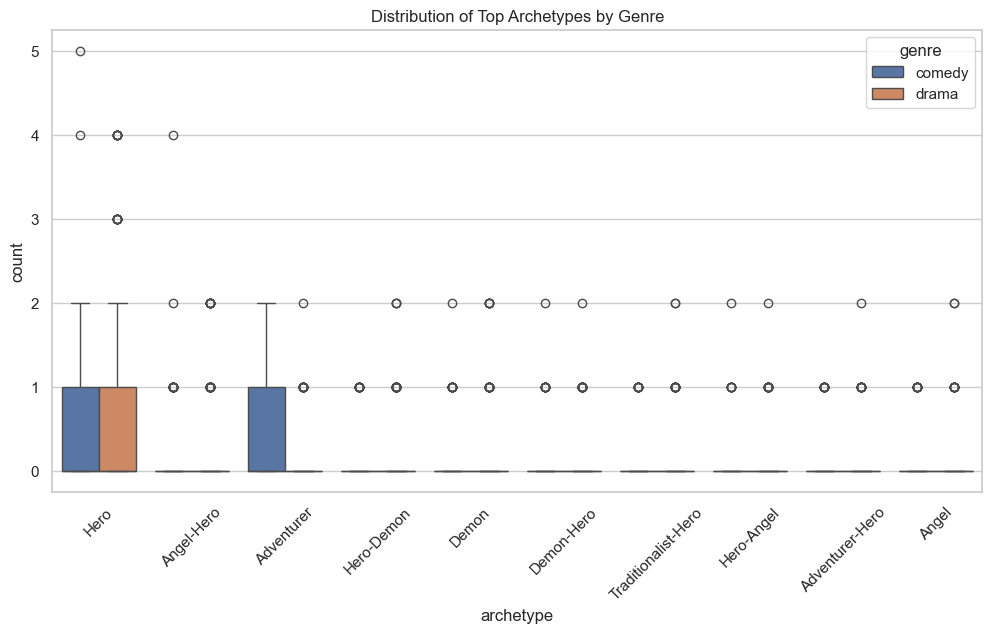

In [91]:
# plot distribution of top archetypes across comedy vs drama
import matplotlib.pyplot as plt
import seaborn as sns
top_archetypes = archetype_freqs_df[archetype_cols].sum(axis=0).sort_values(ascending=False).head(10).index
archetype_freqs_df_melted = archetype_freqs_df.reset_index().melt(id_vars=['story_name', 'genre', 'is_comedy'], value_vars=top_archetypes, var_name='archetype', value_name='count')
plt.figure(figsize=(12, 6))
sns.boxplot(data=archetype_freqs_df_melted, x='archetype', y='count', hue='genre')
plt.xticks(rotation=45)
plt.title('Distribution of Top Archetypes by Genre')
plt.show()

In [86]:
# What are the most common primary archetypes across all stories, normalized by the total number of characters in each story?
# Is it the same as the non-normalized version? Not exactly.
archetype_freqs_df_norm[archetype_cols].sum(axis=0).sort_values(ascending=False).head(20)

primary_archetype
Hero                     28.566667
Adventurer               13.500000
Angel-Hero               13.033333
Hero-Demon                8.733333
Demon-Hero                7.066667
Demon                     6.533333
Traditionalist-Hero       5.933333
Adventurer-Hero           5.833333
Angel                     5.133333
Hero-Angel                5.066667
Angel-Adventurer          4.266667
Lone Wolf-Hero            4.233333
Hero-Angel-Adventurer     3.700000
Demon-Adventurer          3.533333
Diva-Angel-Hero           3.533333
Hero-Adventurer           3.033333
Adventurer-Angel-Hero     2.733333
Adventurer-Hero-Angel     2.566667
Hero-Demon-Adventurer     2.533333
Geek-Hero                 2.533333
dtype: float64

In [87]:
# Filter index to The Office
archetype_freqs_df_office = archetype_freqs_df[archetype_freqs_df.index.str.contains('The Office')]
archetype_freqs_df_office.head()

primary_archetype,genre,is_comedy,Adventurer,Adventurer-Angel,Adventurer-Angel-Diva,Adventurer-Angel-Hero,Adventurer-Angel-Outcast,Adventurer-Brute,Adventurer-Brute-Demon,Adventurer-Brute-Hero,Adventurer-Demon,Adventurer-Demon-Diva,Adventurer-Demon-Fool,Adventurer-Demon-Hero,Adventurer-Demon-Lone Wolf,Adventurer-Demon-Outcast,Adventurer-Diva,Adventurer-Diva-Angel,Adventurer-Diva-Demon,Adventurer-Diva-Hero,Adventurer-Fool-Demon,Adventurer-Fool-Outcast,Adventurer-Geek-Outcast,Adventurer-Hero,Adventurer-Hero-Angel,Adventurer-Hero-Brute,Adventurer-Hero-Demon,Adventurer-Hero-Diva,Adventurer-Hero-Geek,Adventurer-Hero-Outcast,Adventurer-Lone Wolf-Demon,Adventurer-Lone Wolf-Hero,Adventurer-Outcast,Adventurer-Outcast-Angel,Adventurer-Outcast-Demon,Adventurer-Outcast-Diva,Adventurer-Outcast-Hero,Adventurer-Outcast-Lone Wolf,Adventurer-Sophisticate-Hero,Angel,Angel-Adventurer,Angel-Adventurer-Diva,Angel-Adventurer-Hero,Angel-Adventurer-Outcast,Angel-Brute,Angel-Brute-Adventurer,Angel-Brute-Hero,Angel-Diva-Adventurer,Angel-Diva-Hero,Angel-Diva-Outcast,Angel-Diva-Traditionalist,Angel-Fool,Angel-Geek-Adventurer,Angel-Geek-Hero,Angel-Geek-Outcast,Angel-Hero,Angel-Hero-Adventurer,Angel-Hero-Diva,Angel-Hero-Lone Wolf,Angel-Hero-Traditionalist,Angel-Lone Wolf-Hero,Angel-Outcast,Angel-Outcast-Adventurer,Angel-Outcast-Diva,Angel-Outcast-Hero,Angel-Outcast-Traditionalist,Angel-Traditionalist-Hero,Angel-Traditionalist-Outcast,Brute-Adventurer,Brute-Adventurer-Angel,Brute-Adventurer-Demon,Brute-Adventurer-Diva,Brute-Adventurer-Fool,Brute-Adventurer-Hero,Brute-Angel,Brute-Angel-Adventurer,Brute-Angel-Hero,Brute-Angel-Lone Wolf,Brute-Demon,Brute-Demon-Adventurer,Brute-Demon-Diva,Brute-Demon-Hero,Brute-Demon-Outcast,Brute-Demon-Traditionalist,Brute-Diva,Brute-Diva-Adventurer,Brute-Diva-Angel,Brute-Diva-Demon,Brute-Diva-Hero,Brute-Fool-Adventurer,Brute-Hero,Brute-Hero-Adventurer,Brute-Hero-Angel,Brute-Hero-Demon,Brute-Hero-Diva,Brute-Hero-Outcast,Brute-Hero-Traditionalist,Brute-Lone Wolf-Hero,Brute-Lone Wolf-Outcast,Brute-Outcast,Brute-Outcast-Adventurer,Brute-Outcast-Angel,Brute-Outcast-Demon,Brute-Outcast-Diva,Brute-Outcast-Hero,Brute-Traditionalist,Brute-Traditionalist-Demon,Brute-Traditionalist-Hero,Brute-Traditionalist-Outcast,Demon,Demon-Adventurer,Demon-Adventurer-Brute,Demon-Adventurer-Diva,Demon-Adventurer-Hero,Demon-Adventurer-Lone Wolf,Demon-Adventurer-Outcast,Demon-Brute-Adventurer,Demon-Brute-Diva,Demon-Brute-Hero,Demon-Brute-Outcast,Demon-Diva,Demon-Diva-Adventurer,Demon-Diva-Hero,Demon-Diva-Traditionalist,Demon-Fool-Diva,Demon-Fool-Outcast,Demon-Geek-Adventurer,Demon-Geek-Hero,Demon-Hero,Demon-Hero-Adventurer,Demon-Hero-Diva,Demon-Hero-Geek,Demon-Hero-Lone Wolf,Demon-Hero-Outcast,Demon-Hero-Traditionalist,Demon-Lone Wolf-Adventurer,Demon-Lone Wolf-Hero,Demon-Lone Wolf-Outcast,Demon-Outcast,Demon-Outcast-Adventurer,Demon-Outcast-Fool,Demon-Outcast-Hero,Demon-Outcast-Lone Wolf,Demon-Outcast-Traditionalist,Demon-Sophisticate-Hero,Demon-Traditionalist-Diva,Demon-Traditionalist-Hero,Diva,Diva-Adventurer,Diva-Adventurer-Angel,Diva-Adventurer-Demon,Diva-Adventurer-Fool,Diva-Adventurer-Hero,Diva-Adventurer-Outcast,Diva-Angel,Diva-Angel-Adventurer,Diva-Angel-Brute,Diva-Angel-Hero,Diva-Angel-Outcast,Diva-Demon,Diva-Demon-Adventurer,Diva-Demon-Brute,Diva-Demon-Fool,Diva-Demon-Hero,Diva-Demon-Traditionalist,Diva-Fool-Adventurer,Diva-Fool-Outcast,Diva-Geek-Adventurer,Diva-Geek-Demon,Diva-Geek-Hero,Diva-Geek-Outcast,Diva-Hero,Diva-Hero-Adventurer,Diva-Hero-Angel,Diva-Hero-Brute,Diva-Hero-Demon,Diva-Hero-Outcast,Diva-Hero-Traditionalist,Diva-Outcast,Diva-Outcast-Adventurer,Diva-Outcast-Angel,Diva-Outcast-Hero,Diva-Outcast-Traditionalist,Diva-Sophisticate-Adventurer,Diva-Sophisticate-Hero,Diva-Traditionalist,Diva-Traditionalist-Angel,Diva-Traditionalist-Demon,Diva-Traditionalist-Hero,Diva-Traditionalist-Outcast,Fool-Adventurer,Fool-Adventurer-Demon,Fool-Adventurer-Diva,Fool-Adventurer-Outcast,Fool-Angel-Outcast,Fool-Brute-Adventurer,Fool-Demon-Adventurer

### How this visualization was constructed

To compare cast-composition differences between **comedy** and **drama**, we project each story into 2D latent spaces using archetype composition features.

1. **Feature matrices**
   - `archetype_freqs_df[archetype_cols]`: raw counts of primary archetypes per story.
   - `archetype_freqs_df_norm[archetype_cols]`: row-normalized archetype frequencies (controls for different cast sizes).

2. **Standardization**
   - Each feature matrix is standardized with `StandardScaler` so archetypes with larger raw variance do not dominate the embedding.

3. **2D latent projections**
   - **PCA (2D)** gives a linear projection for global structure.
   - **t-SNE (2D)** gives a non-linear projection that can reveal local neighborhood structure.
   - We run both projections for both feature spaces (raw and normalized), then combine results into one plotting table (`latent_plot_df`).

4. **Genre labeling and color-coding**
   - Each point is one story.
   - Points are colored by `genre` to visually compare how comedy vs drama distribute in latent space.

5. **Zoomed t-SNE view**
   - Because many t-SNE points are dense near the center, we add a second figure that zooms to the central region (5th–95th percentile bounds per axis, with small padding) to better inspect subtle genre separation.

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

def build_latent_2d_plot_df(df_in, feature_cols, space_name):
    x = df_in[feature_cols].fillna(0).values
    x_scaled = StandardScaler().fit_transform(x)

    pca = PCA(n_components=2, random_state=42)
    pca_coords = pca.fit_transform(x_scaled)

    # Keep t-SNE settings robust to sample size
    n_samples = x_scaled.shape[0]
    perplexity = min(30, max(5, n_samples // 10))
    if perplexity >= n_samples:
        perplexity = max(1, n_samples - 1)

    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=42, init='pca', learning_rate='auto')
    tsne_coords = tsne.fit_transform(x_scaled)

    meta = df_in[['genre']].copy()
    meta['story_name'] = df_in.index.astype(str)

    pca_df = meta.copy()
    pca_df['x'] = pca_coords[:, 0]
    pca_df['y'] = pca_coords[:, 1]
    pca_df['method'] = 'PCA'
    pca_df['space'] = space_name

    tsne_df = meta.copy()
    tsne_df['x'] = tsne_coords[:, 0]
    tsne_df['y'] = tsne_coords[:, 1]
    tsne_df['method'] = 't-SNE'
    tsne_df['space'] = space_name

    return pd.concat([pca_df, tsne_df], ignore_index=True)

latent_plot_df = pd.concat([
    build_latent_2d_plot_df(archetype_freqs_df, archetype_cols, 'Raw frequencies'),
    build_latent_2d_plot_df(archetype_freqs_df_norm, archetype_cols, 'Normalized frequencies')
])

latent_plot_df.head()

primary_archetype,genre,story_name,x,y,method,space
0,comedy,(500) Days of Summer,-0.195707,-0.661802,PCA,Raw frequencies
1,comedy,10 Things I Hate About You,-0.679895,-0.791496,PCA,Raw frequencies
2,comedy,30 Rock,-0.353327,-0.756591,PCA,Raw frequencies
3,drama,8 Mile,-0.539243,-0.539219,PCA,Raw frequencies
4,drama,A Nightmare on Elm Street,1.292635,-0.665838,PCA,Raw frequencies


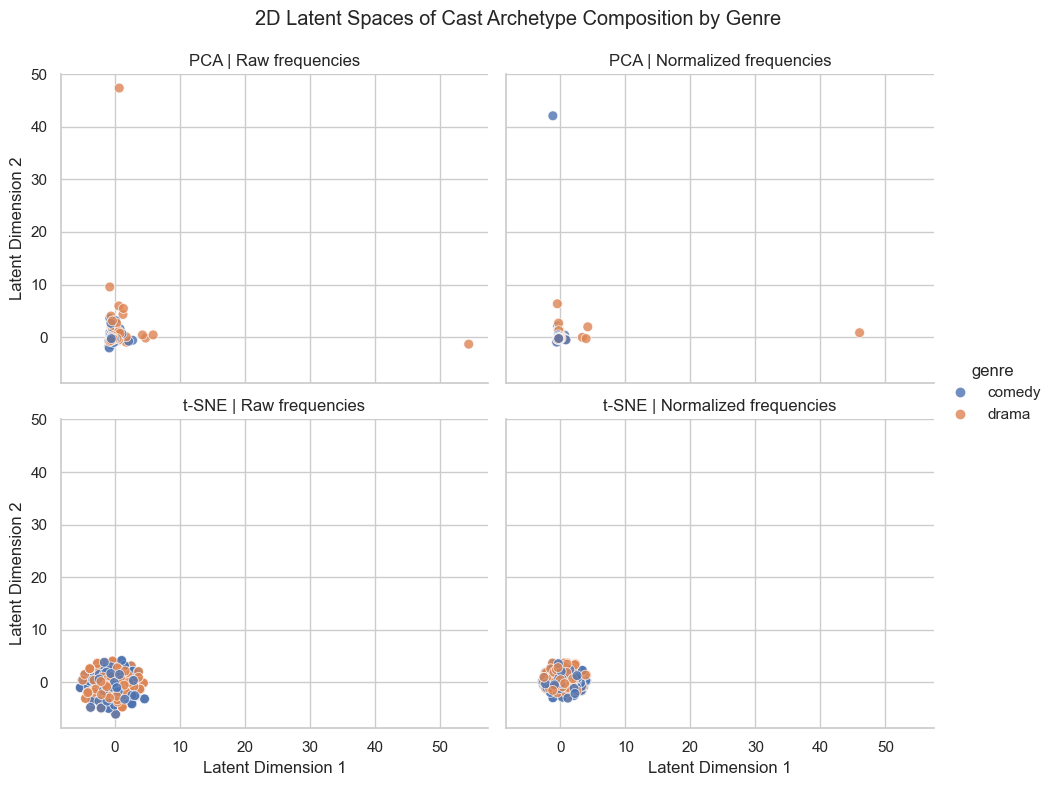

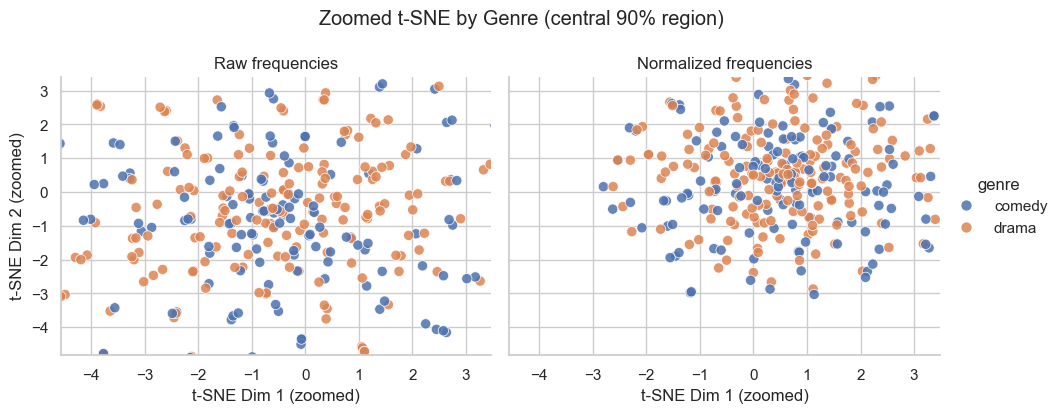

In [89]:
sns.set_theme(style='whitegrid')

# Full view across methods/spaces
g = sns.relplot(
    data=latent_plot_df,
    x='x',
    y='y',
    hue='genre',
    row='method',
    col='space',
    kind='scatter',
    alpha=0.8,
    s=50,
    height=4,
    aspect=1.2
)

g.set_axis_labels('Latent Dimension 1', 'Latent Dimension 2')
g.set_titles(row_template='{row_name}', col_template='{col_name}')
plt.subplots_adjust(top=0.9)
g.figure.suptitle('2D Latent Spaces of Cast Archetype Composition by Genre')
plt.show()

# Zoomed t-SNE view around the dense central region
tsne_df = latent_plot_df[latent_plot_df['method'] == 't-SNE'].copy()

g_zoom = sns.relplot(
    data=tsne_df,
    x='x',
    y='y',
    hue='genre',
    col='space',
    kind='scatter',
    alpha=0.85,
    s=55,
    height=4.2,
    aspect=1.15
)

# Set tighter axes based on central quantiles for each space
for ax, space in zip(g_zoom.axes.flat, sorted(tsne_df['space'].unique())):
    d = tsne_df[tsne_df['space'] == space]
    x_low, x_high = d['x'].quantile([0.05, 0.95])
    y_low, y_high = d['y'].quantile([0.05, 0.95])
    x_pad = (x_high - x_low) * 0.1
    y_pad = (y_high - y_low) * 0.1
    ax.set_xlim(x_low - x_pad, x_high + x_pad)
    ax.set_ylim(y_low - y_pad, y_high + y_pad)

g_zoom.set_axis_labels('t-SNE Dim 1 (zoomed)', 't-SNE Dim 2 (zoomed)')
g_zoom.set_titles(col_template='{col_name}')
plt.subplots_adjust(top=0.82)
g_zoom.figure.suptitle('Zoomed t-SNE by Genre (central 90% region)')
plt.show()

Stories (pure labels): 283
Archetype features kept: 13 / 407
Class balance (is_comedy):
is_comedy
0    0.664311
1    0.335689
Name: proportion, dtype: float64

ROC-AUC (LogReg on CLR features, 5-fold CV):
Mean AUC = 0.666 ± 0.111


/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


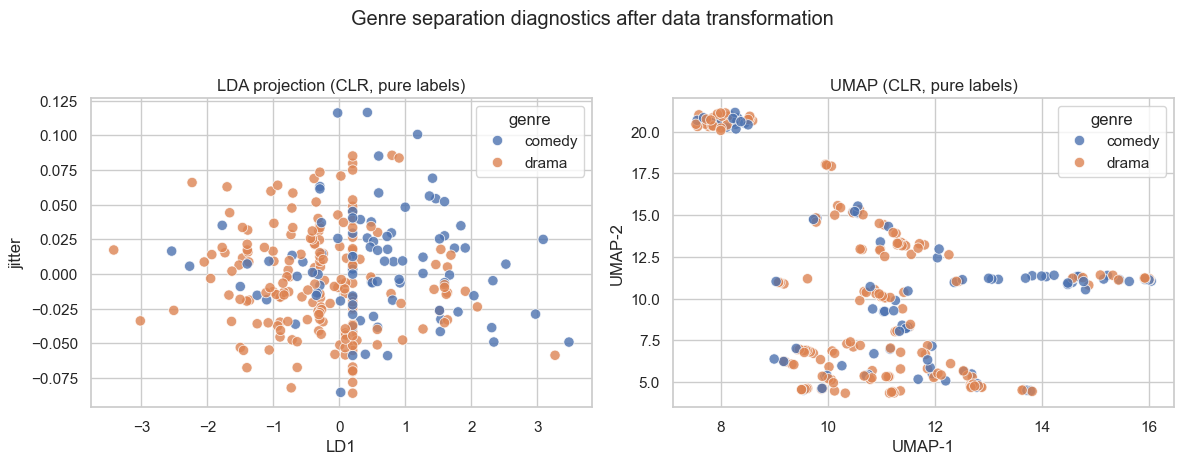

In [90]:
from importlib import import_module

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# --- 1) Build story-level purity labels from imdb_genres ---
story_meta = (
    df[['story_name', 'imdb_genres', 'genre', 'is_comedy']]
    .drop_duplicates('story_name')
    .copy()
)
story_meta['imdb_genres_l'] = story_meta['imdb_genres'].fillna('').str.lower()
story_meta['has_comedy'] = story_meta['imdb_genres_l'].str.contains('comedy')
story_meta['has_drama'] = story_meta['imdb_genres_l'].str.contains('drama')
story_meta['is_pure_genre'] = story_meta['has_comedy'] ^ story_meta['has_drama']

sep_df = archetype_freqs_df.join(
    story_meta.set_index('story_name')[['is_pure_genre']],
    how='left'
).copy()

# Keep comedy/drama stories with pure genre labels only
sep_df = sep_df[sep_df['is_pure_genre'] == True].copy()

# --- 2) Start from composition features and remove rare archetypes ---
X_prop = sep_df[archetype_cols].copy()
X_prop = X_prop.div(X_prop.sum(axis=1), axis=0).fillna(0)

# Keep archetypes present (>0) in at least 5% of stories
min_prevalence = 0.05
present_rate = (X_prop > 0).mean(axis=0)
kept_cols = present_rate[present_rate >= min_prevalence].index.tolist()
X_prop = X_prop[kept_cols]

# --- 3) CLR transform for compositional data ---
eps = 1e-6
X_clr = np.log(X_prop + eps)
X_clr = X_clr.sub(X_clr.mean(axis=1), axis=0)

y = sep_df['is_comedy'].astype(int)

print(f'Stories (pure labels): {len(sep_df)}')
print(f'Archetype features kept: {len(kept_cols)} / {len(archetype_cols)}')
print('Class balance (is_comedy):')
print(y.value_counts(normalize=True).rename('proportion'))

# --- 4) Quantitative separability test (CV ROC-AUC) ---
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=3000, random_state=42)
auc_scores = cross_val_score(clf, X_clr, y, cv=cv, scoring='roc_auc')

print('\nROC-AUC (LogReg on CLR features, 5-fold CV):')
print(f'Mean AUC = {auc_scores.mean():.3f} ± {auc_scores.std():.3f}')

# --- 5) Visual checks: LDA (always) + UMAP (if installed) ---
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# LDA: supervised projection (1D for binary classes)
lda = LinearDiscriminantAnalysis(n_components=1)
z_lda = lda.fit_transform(X_clr, y).ravel()
plot_lda = pd.DataFrame({
    'lda1': z_lda,
    'jitter': np.random.default_rng(42).normal(0, 0.04, size=len(z_lda)),
    'genre': sep_df['genre'].values
})
sns.scatterplot(data=plot_lda, x='lda1', y='jitter', hue='genre', alpha=0.8, s=55, ax=axes[0])
axes[0].set_title('LDA projection (CLR, pure labels)')
axes[0].set_xlabel('LD1')
axes[0].set_ylabel('jitter')

# UMAP: optional non-linear embedding
umap_ok = True
try:
    umap = import_module('umap.umap_')
except Exception:
    umap_ok = False

if umap_ok:
    reducer = umap.UMAP(n_components=2, n_neighbors=20, min_dist=0.1, metric='euclidean', random_state=42)
    z_umap = reducer.fit_transform(X_clr)
    plot_umap = pd.DataFrame({
        'x': z_umap[:, 0],
        'y': z_umap[:, 1],
        'genre': sep_df['genre'].values
    })
    sns.scatterplot(data=plot_umap, x='x', y='y', hue='genre', alpha=0.8, s=55, ax=axes[1])
    axes[1].set_title('UMAP (CLR, pure labels)')
    axes[1].set_xlabel('UMAP-1')
    axes[1].set_ylabel('UMAP-2')
else:
    axes[1].text(0.5, 0.5, 'UMAP not installed\nInstall umap-learn to enable', ha='center', va='center')
    axes[1].set_title('UMAP unavailable')
    axes[1].set_xticks([])
    axes[1].set_yticks([])

# cleaner legends
for ax in axes:
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend(title='genre', loc='best')

plt.suptitle('Genre separation diagnostics after data transformation', y=1.03)
plt.tight_layout()
plt.show()

### Try to improve genre separation

> If comedy and drama overlap in t-SNE, test whether better preprocessing increases separability.

This experiment applies:
- **Pure-genre filtering**: keep stories that are comedy-only or drama-only (drop mixed comedy+drama labels).
- **Compositional transform (CLR)**: convert archetype proportions with a centered log-ratio transform.
- **Rare-feature filtering**: remove archetypes that appear in very few stories.
- **Quantitative check**: evaluate separability with cross-validated ROC-AUC.
- **Visual check**: plot LDA (and UMAP if installed).